# Transmission Coefficient and Figures 2–3

This section provides the code for computing the **transmission coefficient** (Sec. II, Eq. 6).  
The necessary simulating/plotting functions are included in an external helper Python file, which is imported directly.

### Contents (ordered as in the notebook)
- Definition of the **emissivity profile**  
- Code to reproduce **Figure 3c**:  
  - Cylinder partitioned into 8 elements  
  - 4 blackbody elements  
  - 4 continuous on–off materials  
- Code and data used for **Figures 2 and 3**


In [2]:
import os
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import importlib
import helpers_TC

#fancy plot setting
os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"
plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 25  
plt.rcParams['axes.titlesize'] = 25  

#reload library in case of updates.
importlib.reload(helpers_TC)
from helpers_TC import *

In [3]:
#Fig 3c: 4 arctan emissivity profile + 4 BB 
def e(theta, phi, alpha):
    """
    Provides the directional emissivity profile at boundary point  alpha in [0, 2 pi)$ (notation following Sec. II),  
    for a given azimuthal–polar direction (theta, varphi) in [0, pi/2) x [0, 2 pi).
    """    
    if (alpha % (np.pi / 2)) <= np.pi/4: 
        if theta < 0:
            theta = -theta 
            phi = phi + np.pi 
            
        phi = phi % (2 * np.pi)  
        beta = np.cos(phi) * np.sin(theta) #beta following Fig. 1
        return 1/np.pi * (np.arctan(100*beta) + np.pi/2)
            
    else: 
        return 1

def a(theta, phi, alpha):
    "directional absorption profile constrained by the Generalized Kirchhoff's law"
    return e(-theta, phi, alpha)

def r(theta, phi, alpha):
    "directional reflection profile"
    return 1 - a(theta, phi, alpha)  

In [4]:
#PARAMETERS: 
z = 0
n_elem = 8 # Number of elements
dpi_kx = 50 # Resolution for kx integration (see Eq. 4) (same value for ky). 
dpi_alpha = 35 # Resolution of points for each element (see Eq. 6). 

G_matrix = S_z_several_material(n_elem, z, e, a, r, dpi_kx, dpi_alpha)
T = G_matrix - G_matrix.T

#This is a more efficient-alternative for a single material configuration (uses symmetry)
#G_matrix_one_material = S_z_one_material(n_elem, z, e, a, r, dpi_kx, dpi_alpha) 
#T= G_matrix_one_material - G_matrix_one_material.T  

Non-reciprocity factor value: 0.6225386451444785


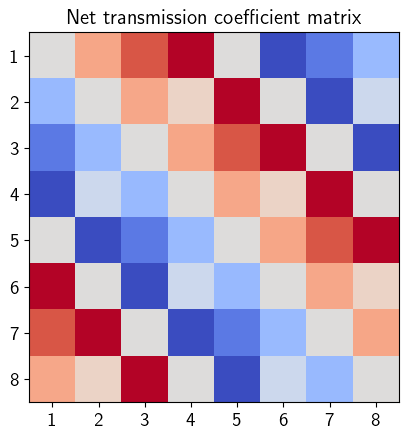

In [6]:
non_reciprocity_factor_value(T)

plt.title('Net transmission coefficient matrix', fontsize = 15)
plt.imshow(T, cmap = 'coolwarm')
positions = np.arange(8)
labels = np.arange(1, 9)
plt.xticks(positions, labels, fontsize = 14)
plt.yticks(positions, labels, fontsize = 14)
plt.show()

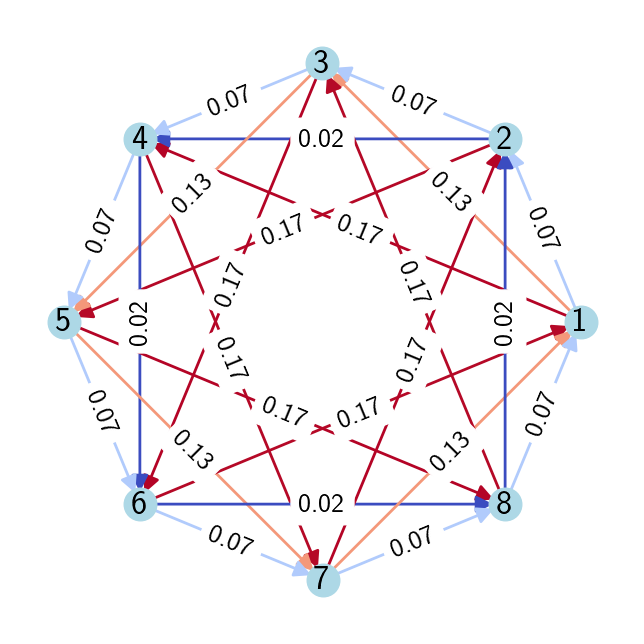

In [7]:
net_heat_transmission_coefficient_graph(T)

## Plots for Figures 2 and 3

The following cells generate the plots corresponding to **Figure 2** and **Figure 3** of the manuscript.  
These plots use the transmission coefficient data, imported from data folder. 

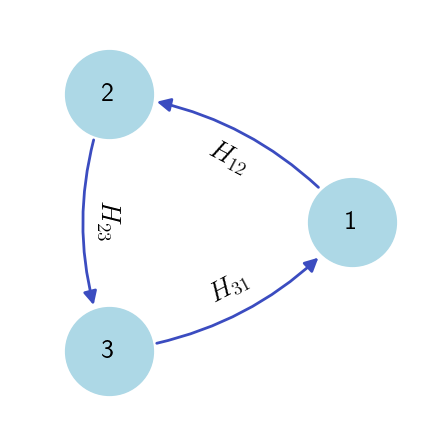

In [8]:
#Fig. 2 (Weyl Semimetal, 3 elements emission.)
WS_3_elem_matrix = np.load('data/Graph_3_WS.npy')
T = np.copy(WS_3_elem_matrix)
T[T <= 0] = 0  #only plot positive edges

G = nx.from_numpy_array(T, create_using=nx.DiGraph)
G = nx.relabel_nodes(G, lambda x: x + 1)
pos = nx.circular_layout(G)

edge_weights = np.array([d['weight'] for _, _, d in G.edges(data=True)])
norm = mcolors.Normalize(vmin=edge_weights.min(), vmax=edge_weights.max())
cmap = plt.cm.coolwarm
edge_colors = [cmap(norm(d['weight'])) for _, _, d in G.edges(data=True)]


fig, ax = plt.subplots(figsize=(5, 5), dpi=100)
nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=4000, ax=ax)
nx.draw_networkx_edges(G, pos,edge_color=edge_colors,width=2,edge_cmap=cmap,ax=ax,arrows=True,arrowsize=20,
    connectionstyle='arc3,rad=0.2',  #curved edges
    min_source_margin=35,  #edge separation 
    min_target_margin=35)
nx.draw_networkx_labels(G, pos, font_size=20, font_family='sans-serif')
edge_labels = {(u, v): f'$H_{{{u}{v}}}$' for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='black', font_size=20)

ax.margins(0.25)  
ax.axis('off')
plt.tight_layout()
plt.savefig("figures/3_element_transmission_graphs.pdf", format='pdf', bbox_inches='tight')
plt.show()

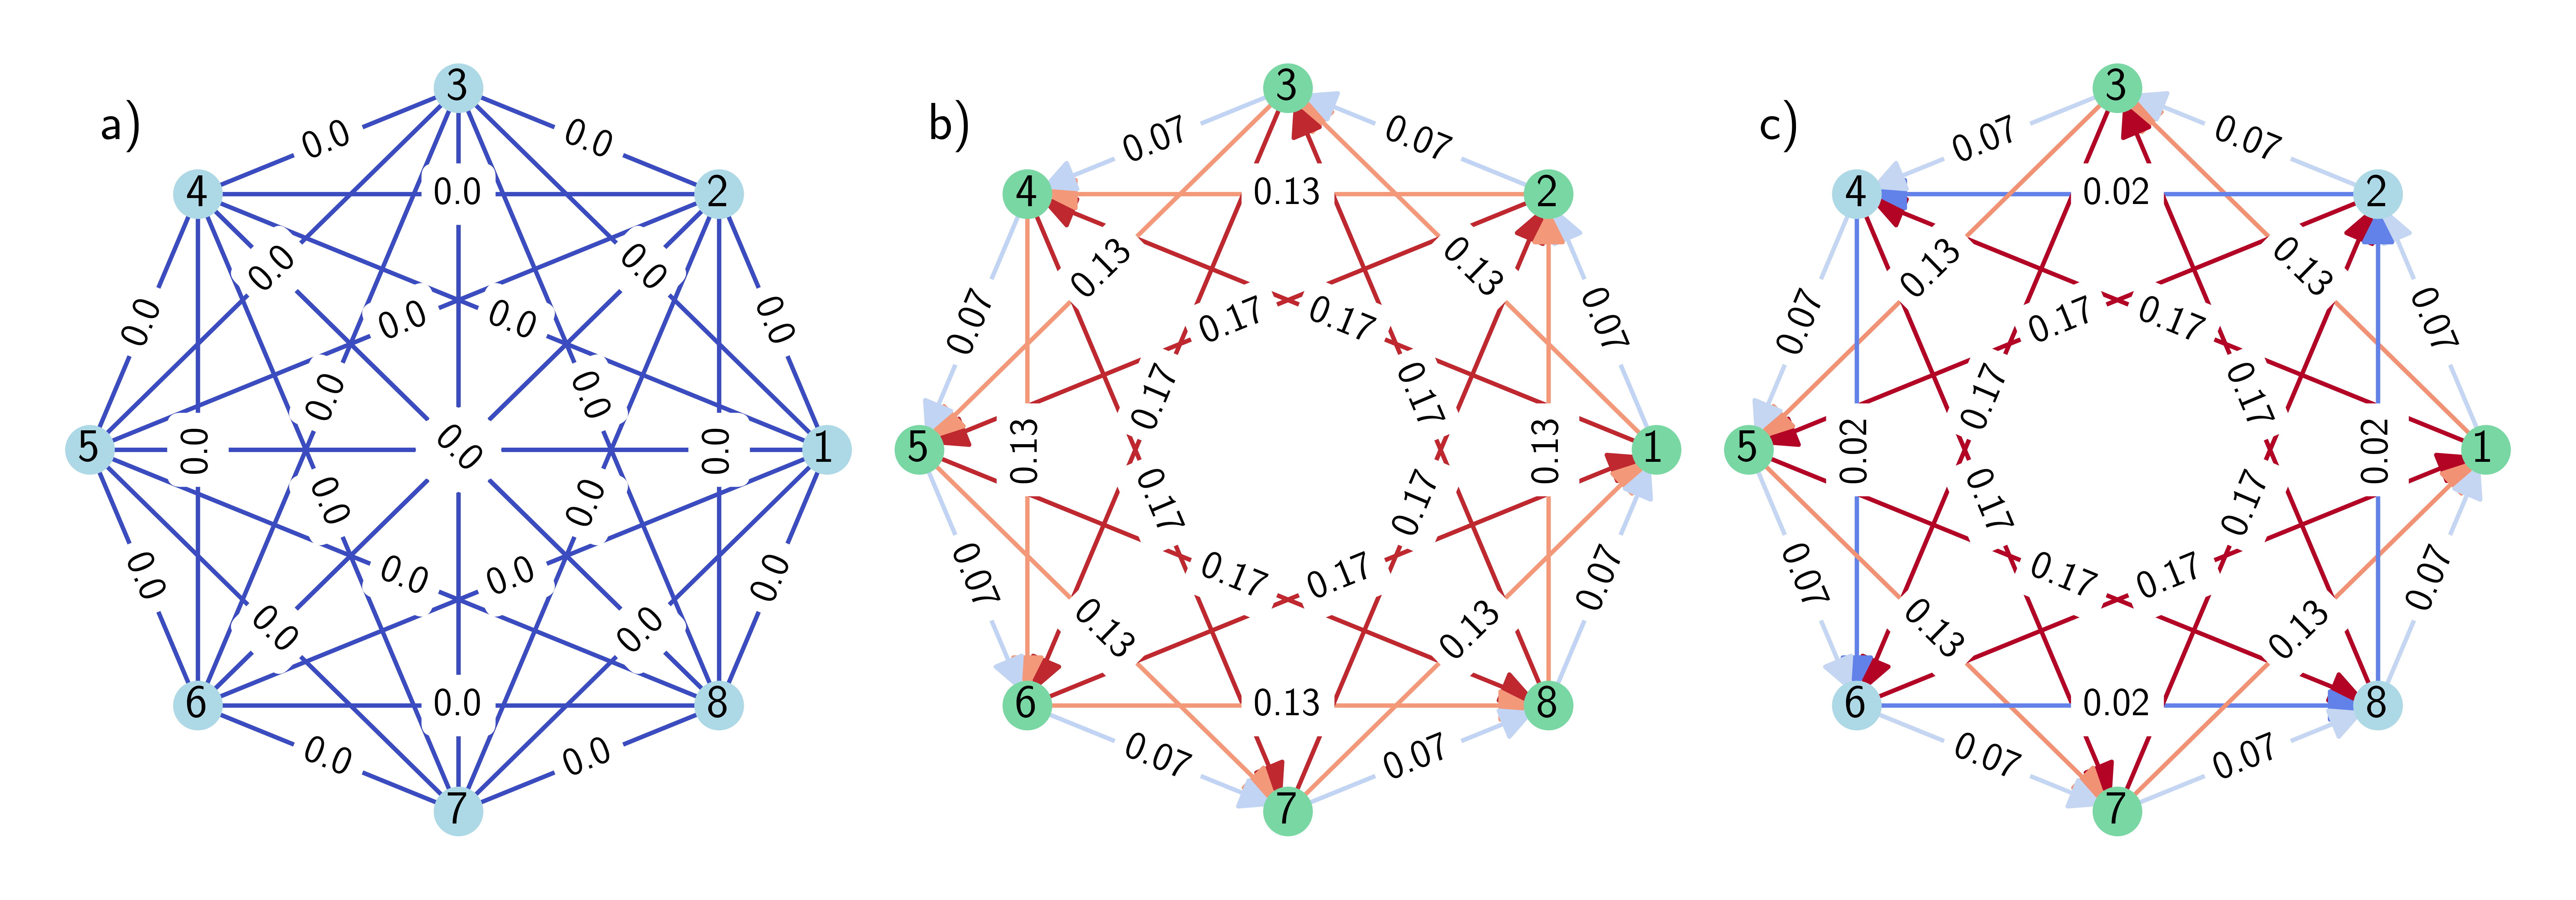

In [9]:
#Fig. 3 (8 element graph representation, with 3 distinct cases, as detailed in Fig. 3.)

T1 = np.load('data/Graph_8_elements_BB.npy')
T2 = np.load('data/Graph_8_elements_Arctan.npy')
T3 = np.load('data/Graph_8_elements_4Arctan4BB.npy')

matrices = [T1, T2, T3]
labels = ['a)', 'b)', 'c)']

fig, axes = plt.subplots(1, 3, figsize=(21, 7.7), dpi=400)

all_weights = []
for T in matrices:
    G = nx.from_numpy_array(T, create_using=nx.DiGraph)
    all_weights += [d['weight'] for _, _, d in G.edges(data=True)]

norm = mcolors.Normalize(vmin=0*min(all_weights), vmax=max(all_weights))
cmap = plt.cm.coolwarm

for i, (T, ax) in enumerate(zip(matrices, axes)):
    for k in range(len(T)):
        for j in range(len(T)):
            if T[k][j] <= 0:
                T[k][j] = 0  # Set any non-positive values in T to zero

    G = nx.from_numpy_array(T, create_using=nx.DiGraph)
    G = nx.relabel_nodes(G, lambda x: x + 1)

    edge_weights = np.array([d['weight'] for _, _, d in G.edges(data=True)])
    edge_colors = [cmap(norm(d['weight'])) for _, _, d in G.edges(data=True)]
    
    pos = nx.circular_layout(G)
    arrowsize_values = [1, 40, 40]

    if i == 1:
        node_colors = ["#79D7A3"] * len(G.nodes)
    elif i == 2:
        node_colors = ["#79D7A3" if n % 2 == 1 else 'lightblue' for n in G.nodes]
    else:
        node_colors = ['lightblue'] * len(G.nodes)

    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=750, ax=ax)
    nx.draw_networkx_edges(G, pos, edgelist=G.edges(), edge_color=edge_colors, width=2.5, edge_cmap=cmap, ax=ax, arrowsize=arrowsize_values[i])
    nx.draw_networkx_labels(G, pos, font_size=27, font_family='sans-serif', ax=ax)

    if i == 0: 
        edge_labels = {(u, v): f'{d["weight"]:.1f}' for u, v, d in G.edges(data=True)}
    else: 
        edge_labels = {(u, v): f'{d["weight"]:.2f}' for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='black', font_size=23, ax=ax)
    ax.text(0.1, 0.9, labels[i], transform=ax.transAxes, fontsize=30, fontweight = 'bold', va='top', ha='left')
    ax.axis('off')

plt.tight_layout()
plt.subplots_adjust(wspace=-0.07)
plt.savefig("figures/transmission_graphs.pdf", format='pdf', bbox_inches='tight')
plt.show()